# 🛒 Sales & Retail Analytics
## Module 2: Exploratory Data Analysis (EDA)

**Author:** Muhammad Umar Shahid  
**Email:** connect2umarshahid@gmail.com  
**GitHub:** github.com/Umar-Shahid  

---

### What This Notebook Covers
1. Sales trends over time (yearly, monthly, quarterly)
2. Category & sub-category performance
3. Regional & geographic analysis
4. Customer segment analysis
5. Discount impact on profit
6. Shipping performance analysis
7. Correlation heatmap
8. Top 10 customers & products
9. Day of week & seasonal patterns

> **All charts are saved to reports/ folder for Power BI & portfolio use**
---

In [1]:
# ================================================================
# LIBRARY IMPORTS
# ================================================================

# pandas → load and manipulate the clean dataset
import pandas as pd

# numpy → numerical operations used in chart calculations
import numpy as np

# matplotlib.pyplot → base plotting engine
# All charts ultimately render through matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  # formats axis tick labels (e.g. $1,000)

# seaborn → statistical charts with beautiful defaults
# Built on matplotlib — less code for better looking charts
import seaborn as sns

# os → create output folders for saving charts
import os

import warnings
warnings.filterwarnings('ignore')

# ── Global style ─────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 50)

# ── Output folders ───────────────────────────────────────────
os.makedirs('../reports', exist_ok=True)

print("✅ Libraries loaded")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ Libraries loaded
   pandas  : 3.0.2
   numpy   : 2.4.4


---
## Load Clean Dataset

We load from `data/processed/superstore_clean.csv` — the output  
of Notebook 01. This has all original columns PLUS our engineered features.

**Never modify raw data** — always work from the processed file.
---

In [2]:
# Load the cleaned dataset produced by Notebook 01
# This file has all engineered features already:
# Ship Days, Profit Margin%, Season, Profit Tier etc.
CLEAN_PATH = '/kaggle/input/datasets/muhammadumarshahid/global-superstore-cleaned/superstore_clean.csv'

df = pd.read_csv(CLEAN_PATH)

# Re-parse dates — CSV doesn't store datetime type,
# it stores them as strings again so we convert back
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

print(f"✅ Clean dataset loaded")
print(f"   Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Columns : {df.columns.tolist()}")
print(f"\n📅 Date range: {df['Order Date'].min().date()} → "
      f"{df['Order Date'].max().date()}")

✅ Clean dataset loaded
   Shape   : 8,286 rows × 35 columns
   Columns : ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month', 'Order Quarter', 'Order DOW', 'Ship Days', 'Profit Margin %', 'Revenue per Unit', 'Discount Amount', 'Is Profitable', 'Profit Tier', 'Sales Segment', 'Ship Speed', 'Season', 'Is_Sales_Outlier']

📅 Date range: 2014-01-02 → 2017-12-30


---
## Part 1: Sales Trends Over Time

**Business Question:** Is the business growing? Which periods perform best?

**Charts:**
- Yearly revenue & profit trend
- Monthly sales pattern (all years combined)
- Quarterly performance breakdown

**Key methods:**
- `.groupby()` → aggregate by time period
- `.resample()` → group datetime data by frequency (M=monthly, Q=quarterly)
- `plt.subplots()` → create multiple charts in one figure
---

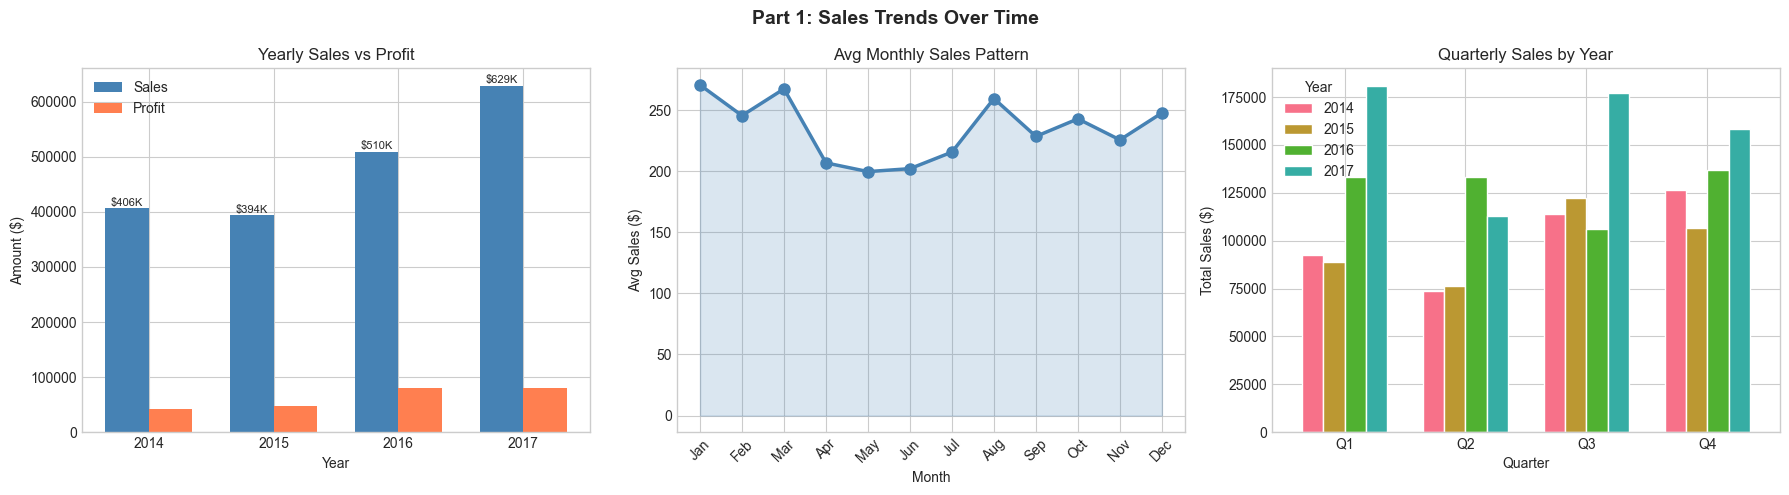

✅ Chart saved → reports/02_sales_trends.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Part 1: Sales Trends Over Time', 
             fontsize=14, fontweight='bold')

# ── Chart 1: Yearly Sales & Profit ───────────────────────────
# .groupby() → splits DataFrame into groups by column value
# [['Sales','Profit']] → select only these two columns
# .sum() → total for each year
yearly = df.groupby('Order Year')[['Sales', 'Profit']].sum()

x = range(len(yearly.index))
width = 0.35

# ax.bar() → vertical bar chart
# zip unpacking gives us side-by-side bars
bars1 = axes[0].bar([i - width/2 for i in x], yearly['Sales'],
                     width, label='Sales', color='steelblue')
bars2 = axes[0].bar([i + width/2 for i in x], yearly['Profit'],
                     width, label='Profit', color='coral')

axes[0].set_title('Yearly Sales vs Profit')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Amount ($)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(yearly.index)
axes[0].legend()

# Add value labels on bars
# .get_height() → gets bar height to position label above it
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1000,
                 f'${bar.get_height()/1000:.0f}K',
                 ha='center', va='bottom', fontsize=8)

# ── Chart 2: Monthly Sales Pattern ───────────────────────────
# Group by month number (1-12) across all years
# This shows SEASONAL patterns regardless of year
monthly = df.groupby('Order Month')['Sales'].mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

axes[1].plot(month_names, monthly.values,
             marker='o',          # circle marker at each data point
             linewidth=2.5,
             color='steelblue',
             markersize=8)
axes[1].fill_between(range(12), monthly.values,
                      alpha=0.2,  # transparency of shaded area
                      color='steelblue')
axes[1].set_title('Avg Monthly Sales Pattern')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Sales ($)')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_names, rotation=45)

# ── Chart 3: Quarterly Performance ───────────────────────────
# .groupby() with two columns → creates multi-level grouping
quarterly = df.groupby(['Order Year', 'Order Quarter'])['Sales'].sum()
quarterly = quarterly.reset_index()  # converts multi-index back to columns

# pivot_table → reshapes data: rows=Quarter, columns=Year
# Makes it easy to plot grouped bars
pivot_q = quarterly.pivot_table(
    index='Order Quarter',
    columns='Order Year',
    values='Sales'
)

pivot_q.plot(kind='bar', ax=axes[2],
             width=0.7, edgecolor='white')
axes[2].set_title('Quarterly Sales by Year')
axes[2].set_xlabel('Quarter')
axes[2].set_ylabel('Total Sales ($)')
axes[2].set_xticklabels(['Q1','Q2','Q3','Q4'], rotation=0)
axes[2].legend(title='Year')

plt.tight_layout()
plt.savefig('/kaggle/working/02_sales_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/02_sales_trends.png")

---
## Part 2: Category & Sub-Category Analysis

**Business Question:** Which products make money and which lose money?

**Charts:**
- Sales & profit by Category
- Sub-category profitability ranking
- Profit margin heatmap by Category × Segment

**Key insight to look for:** High sales ≠ high profit  
(Furniture sells a lot but has low/negative margins on some sub-categories)
---

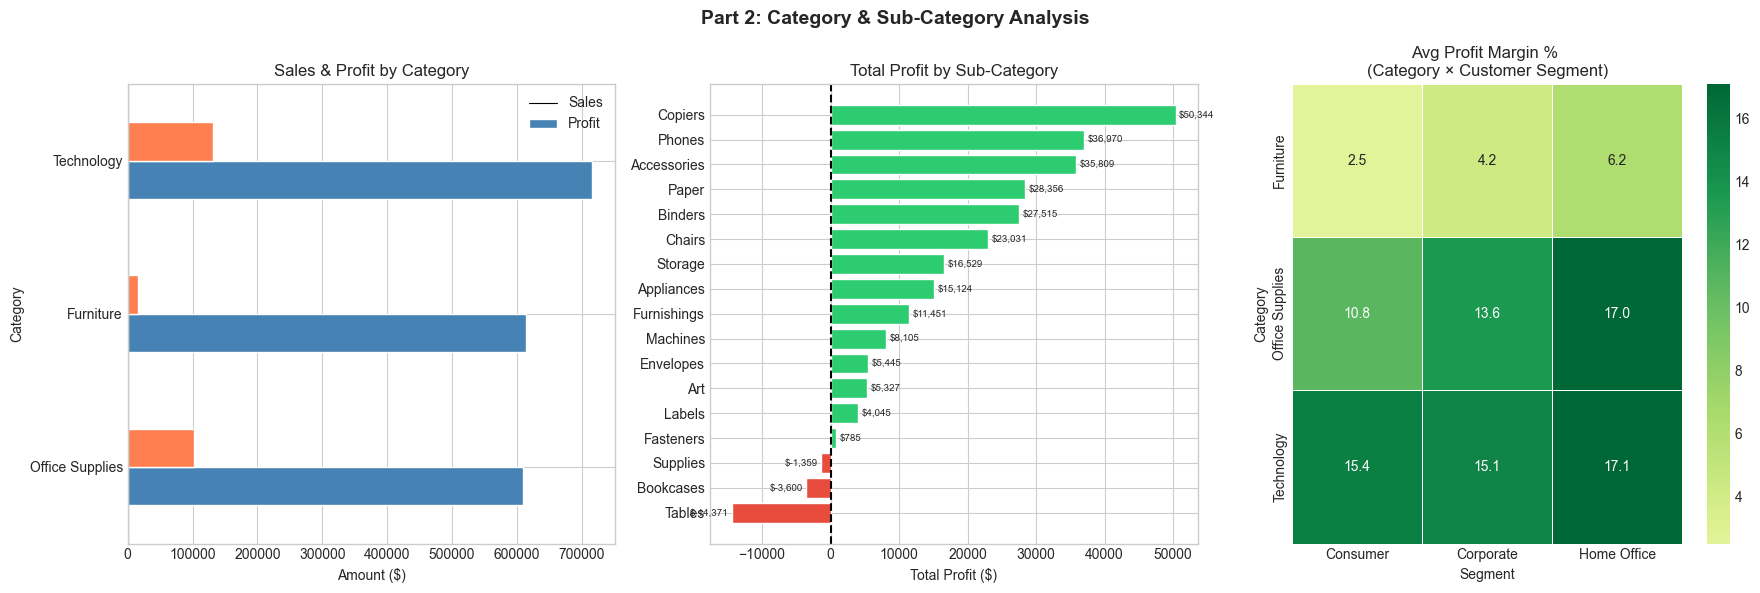

✅ Chart saved → reports/03_category_analysis.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Part 2: Category & Sub-Category Analysis',
             fontsize=14, fontweight='bold')

# ── Chart 1: Sales & Profit by Category ──────────────────────
cat_perf = df.groupby('Category')[['Sales','Profit']].sum().sort_values('Sales')

cat_perf.plot(kind='barh', ax=axes[0],
              color=['steelblue','coral'],
              edgecolor='white')
axes[0].set_title('Sales & Profit by Category')
axes[0].set_xlabel('Amount ($)')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].legend(['Sales','Profit'])

# ── Chart 2: Sub-Category Profit Ranking ─────────────────────
# This is the most important chart — shows which sub-categories LOSE money
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

# Conditional coloring: red=loss, green=profit
colors = ['#e74c3c' if x < 0 else '#2ecc71' 
          for x in subcat_profit.values]

axes[1].barh(subcat_profit.index, subcat_profit.values,
             color=colors, edgecolor='white')
axes[1].set_title('Total Profit by Sub-Category')
axes[1].set_xlabel('Total Profit ($)')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')

# Add profit labels
for i, (val, name) in enumerate(zip(subcat_profit.values,
                                     subcat_profit.index)):
    axes[1].text(val + (500 if val >= 0 else -500), i,
                 f'${val:,.0f}',
                 va='center',
                 ha='left' if val >= 0 else 'right',
                 fontsize=7)

# ── Chart 3: Profit Margin Heatmap ───────────────────────────
# pivot_table → reshapes data into matrix format for heatmap
# aggfunc='mean' → average profit margin for each cell
margin_pivot = df.pivot_table(
    index='Category',
    columns='Segment',
    values='Profit Margin %',
    aggfunc='mean'
).round(1)

# sns.heatmap() → color-coded matrix
# annot=True     → show values inside cells
# fmt='.1f'      → 1 decimal place
# cmap='RdYlGn'  → Red(bad) → Yellow(neutral) → Green(good)
# center=0       → 0% margin = yellow (neutral point)
sns.heatmap(margin_pivot,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            center=0,
            ax=axes[2],
            linewidths=0.5)
axes[2].set_title('Avg Profit Margin % \n(Category × Customer Segment)')

plt.tight_layout()
plt.savefig('/kaggle/working/03_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/03_category_analysis.png")

---
## Part 3: Regional & Geographic Analysis

**Business Question:** Which regions and states drive revenue and profit?

**Charts:**
- Sales & profit by Region
- Top 10 states by sales
- Regional profit margin comparison

**Key methods:**
- `.nlargest()` → returns N rows with largest values
- `sns.barplot()` → bar chart with confidence intervals
---

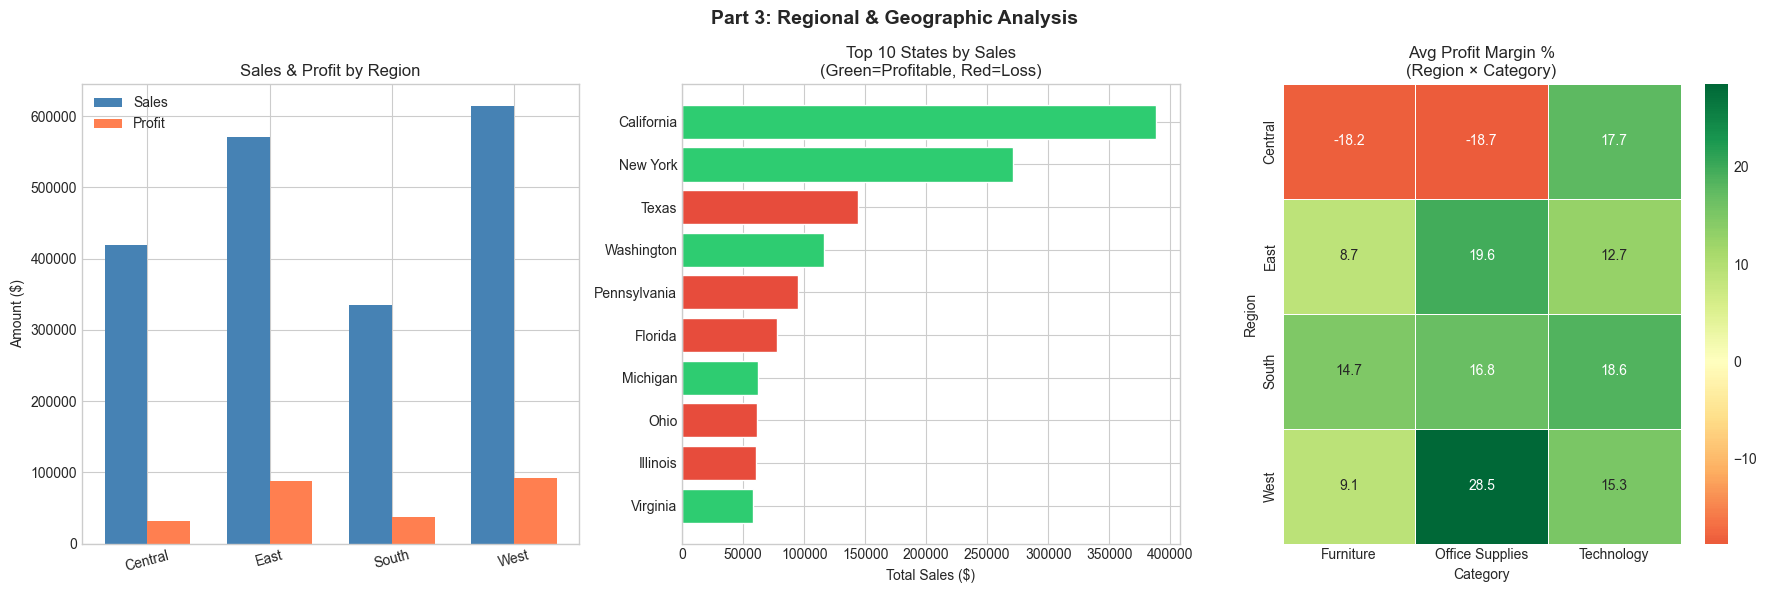

✅ Chart saved → reports/04_regional_analysis.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Part 3: Regional & Geographic Analysis',
             fontsize=14, fontweight='bold')

# ── Chart 1: Sales by Region ──────────────────────────────────
region_perf = df.groupby('Region')[['Sales','Profit']].sum()

x = range(len(region_perf))
width = 0.35
axes[0].bar([i - width/2 for i in x], region_perf['Sales'],
            width, label='Sales', color='steelblue')
axes[0].bar([i + width/2 for i in x], region_perf['Profit'],
            width, label='Profit', color='coral')
axes[0].set_title('Sales & Profit by Region')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(region_perf.index, rotation=15)
axes[0].set_ylabel('Amount ($)')
axes[0].legend()

# ── Chart 2: Top 10 States by Sales ──────────────────────────
# .groupby('State') → one row per state
# .nlargest(10) → keep only top 10 by Sales value
top_states = (df.groupby('State')['Sales']
                .sum()
                .nlargest(10)
                .sort_values())

colors_states = ['#2ecc71' if df[df['State']==s]['Profit'].sum() > 0
                 else '#e74c3c' for s in top_states.index]

axes[1].barh(top_states.index, top_states.values,
             color=colors_states, edgecolor='white')
axes[1].set_title('Top 10 States by Sales\n(Green=Profitable, Red=Loss)')
axes[1].set_xlabel('Total Sales ($)')

# ── Chart 3: Profit Margin by Region & Category ───────────────
region_cat = df.pivot_table(
    index='Region',
    columns='Category',
    values='Profit Margin %',
    aggfunc='mean'
).round(1)

sns.heatmap(region_cat,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            center=0,
            ax=axes[2],
            linewidths=0.5)
axes[2].set_title('Avg Profit Margin %\n(Region × Category)')

plt.tight_layout()
plt.savefig('/kaggle/working/04_regional_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/04_regional_analysis.png")

---
## Part 4: Customer Segment Analysis

**Business Question:** Which customer type is most valuable?

**Segments in this dataset:**
- **Consumer** → individual buyers
- **Corporate** → business buyers  
- **Home Office** → small business/home workers

**Key metric:** Not just who buys most, but who is most PROFITABLE
---

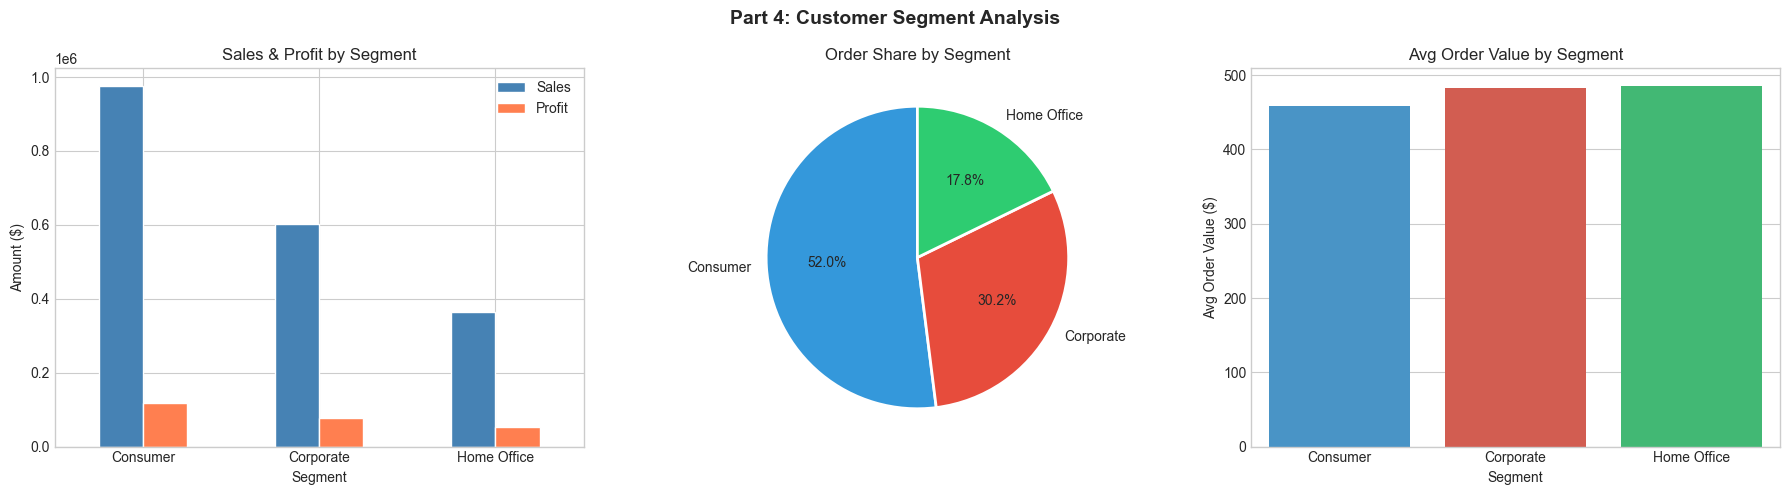

✅ Chart saved → reports/05_segment_analysis.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Part 4: Customer Segment Analysis',
             fontsize=14, fontweight='bold')

# ── Chart 1: Sales & Profit by Segment ───────────────────────
seg_perf = df.groupby('Segment')[['Sales','Profit']].sum()

seg_perf.plot(kind='bar', ax=axes[0],
              color=['steelblue','coral'],
              edgecolor='white', rot=0)
axes[0].set_title('Sales & Profit by Segment')
axes[0].set_ylabel('Amount ($)')
axes[0].legend(['Sales','Profit'])

# ── Chart 2: Order Count by Segment ──────────────────────────
# value_counts() → counts occurrences of each unique value
seg_counts = df['Segment'].value_counts()

# pie chart → shows proportion/share
# autopct='%1.1f%%' → shows percentage with 1 decimal
# startangle=90     → starts pie from top
axes[1].pie(seg_counts.values,
            labels=seg_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=['#3498db','#e74c3c','#2ecc71'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Order Share by Segment')

# ── Chart 3: Avg Order Value by Segment ──────────────────────
# We calculate average sales PER ORDER not per row
# because one order can have multiple rows (products)
avg_order = df.groupby(['Segment','Order ID'])['Sales'].sum()
avg_order = avg_order.reset_index()
avg_order = avg_order.groupby('Segment')['Sales'].mean()

# sns.barplot() → bar chart with error bars (confidence intervals)
# This shows both the average AND the uncertainty around it
sns.barplot(x=avg_order.index,
            y=avg_order.values,
            ax=axes[2],
            palette=['#3498db','#e74c3c','#2ecc71'])
axes[2].set_title('Avg Order Value by Segment')
axes[2].set_ylabel('Avg Order Value ($)')
axes[2].set_xlabel('Segment')

plt.tight_layout()
plt.savefig('/kaggle/working/05_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/05_segment_analysis.png")

---
## Part 5: Discount Impact Analysis

**Business Question:** Are discounts helping or hurting profitability?

**Key hypothesis:** Higher discounts → lower profit margins  
We'll test this visually and statistically.

**Key methods:**
- `sns.scatterplot()` → shows relationship between two numeric variables
- `np.corrcoef()` → calculates Pearson correlation coefficient
- `sns.regplot()` → scatter plot WITH regression line fitted
---

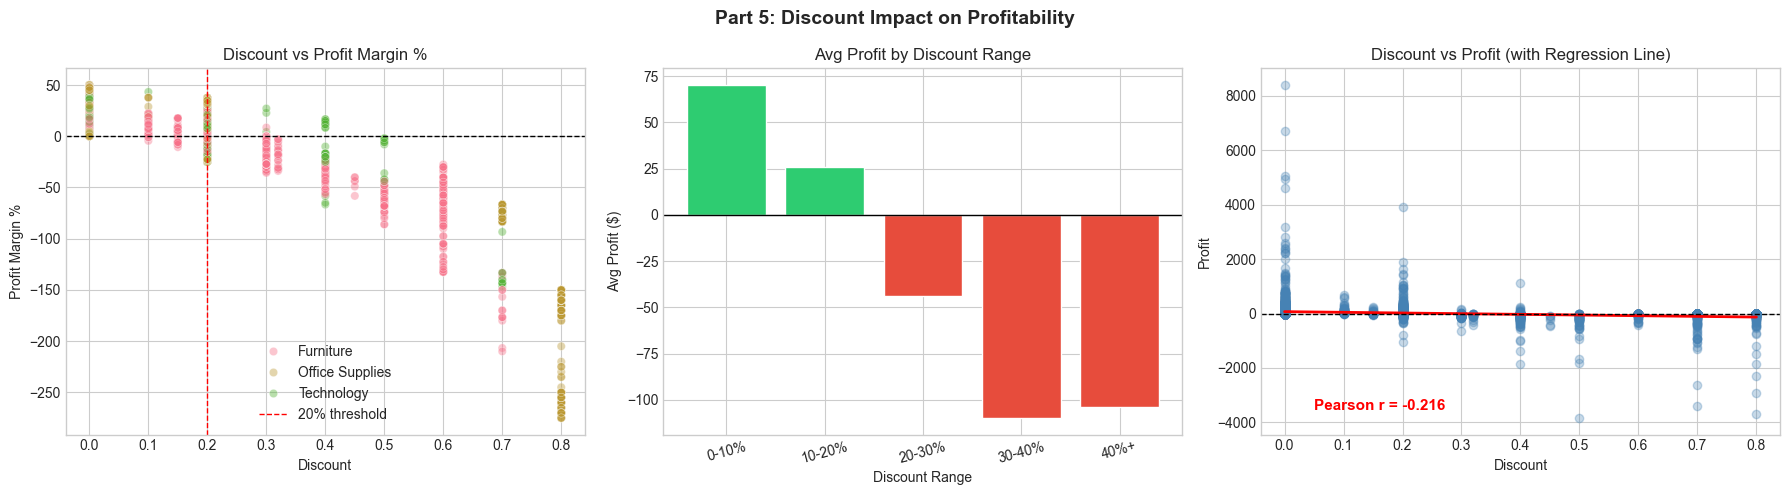

✅ Chart saved → reports/06_discount_analysis.png

📊 Correlation (Discount vs Profit): -0.216
   Interpretation: Weak relationship


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Part 5: Discount Impact on Profitability',
             fontsize=14, fontweight='bold')

# ── Chart 1: Discount vs Profit Scatter ──────────────────────
# sns.scatterplot() → plots one point per row
# hue='Category' → color-codes points by category
# alpha=0.4 → 40% transparency so overlapping points visible
sns.scatterplot(data=df,
                x='Discount',
                y='Profit Margin %',
                hue='Category',
                alpha=0.4,
                ax=axes[0])
axes[0].set_title('Discount vs Profit Margin %')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].axvline(0.2, color='red', linewidth=1,
                linestyle='--', label='20% threshold')
axes[0].legend()

# ── Chart 2: Profit by Discount Bucket ───────────────────────
# pd.cut() → bin discount into ranges
# We create 5 equal-width discount ranges
df['Discount Bucket'] = pd.cut(
    df['Discount'],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 1.0],
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '40%+'],
    include_lowest=True
)

disc_profit = df.groupby('Discount Bucket',
                          observed=True)['Profit'].mean()

colors_disc = ['#2ecc71' if x > 0 else '#e74c3c'
               for x in disc_profit.values]

axes[1].bar(disc_profit.index, disc_profit.values,
            color=colors_disc, edgecolor='white')
axes[1].set_title('Avg Profit by Discount Range')
axes[1].set_xlabel('Discount Range')
axes[1].set_ylabel('Avg Profit ($)')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].tick_params(axis='x', rotation=15)

# ── Chart 3: Regression Plot ──────────────────────────────────
# sns.regplot() → scatter + fitted regression line
# Shows the TREND between discount and profit
# ci=95 → shaded area = 95% confidence interval of the trend line
sns.regplot(data=df,
            x='Discount',
            y='Profit',
            ax=axes[2],
            scatter_kws={'alpha': 0.3, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2},
            ci=95)
axes[2].set_title('Discount vs Profit (with Regression Line)')
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')

# Calculate and display correlation
# np.corrcoef() → returns correlation matrix
# [0,1] extracts the correlation between x and y
corr = np.corrcoef(df['Discount'], df['Profit'])[0, 1]
axes[2].text(0.05, axes[2].get_ylim()[0] * 0.8,
             f'Pearson r = {corr:.3f}',
             fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/06_discount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved → reports/06_discount_analysis.png")
print(f"\n📊 Correlation (Discount vs Profit): {corr:.3f}")
print(f"   Interpretation: {'Strong negative' if corr < -0.5 else 'Moderate negative' if corr < -0.3 else 'Weak'} relationship")

---
## Part 6: Top Customers & Products

**Business Question:** Who are our most valuable customers?  
Which products generate the most revenue?

**Key methods:**
- `.nlargest()` → top N values
- `.groupby()` + `.agg()` → multiple aggregations at once
- `agg({'col': 'func'})` → different function per column
---

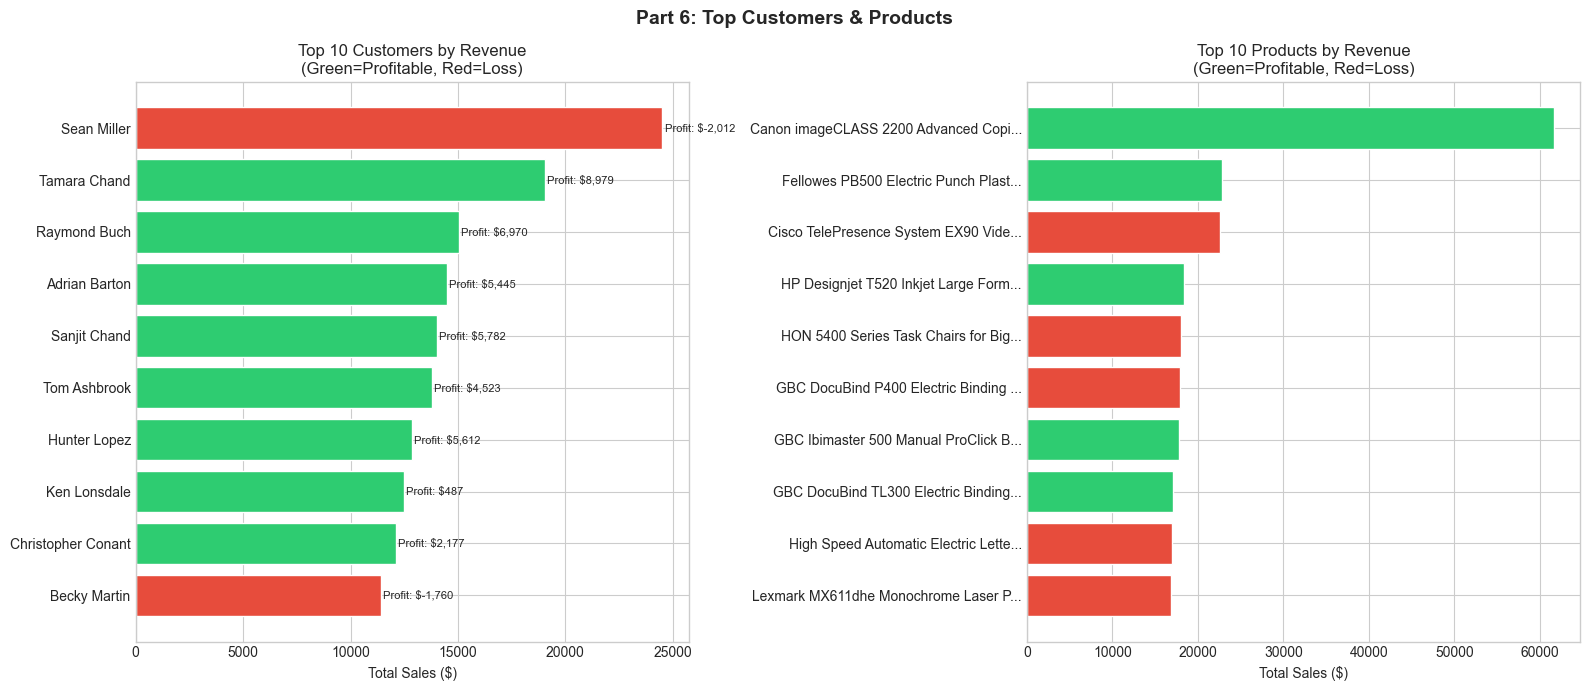

✅ Chart saved → reports/07_top_customers_products.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Part 6: Top Customers & Products',
             fontsize=14, fontweight='bold')

# ── Chart 1: Top 10 Customers by Revenue ─────────────────────
# .agg() → apply multiple different aggregations at once
# {'Sales': 'sum'} → sum of Sales
# {'Profit': 'sum'} → sum of Profit
# {'Order ID': 'nunique'} → count of unique orders
top_customers = (df.groupby('Customer Name')
                   .agg({'Sales': 'sum',
                         'Profit': 'sum',
                         'Order ID': 'nunique'})
                   .nlargest(10, 'Sales')
                   .sort_values('Sales'))

colors_cust = ['#2ecc71' if p > 0 else '#e74c3c'
               for p in top_customers['Profit']]

bars = axes[0].barh(top_customers.index,
                    top_customers['Sales'],
                    color=colors_cust,
                    edgecolor='white')
axes[0].set_title('Top 10 Customers by Revenue\n(Green=Profitable, Red=Loss)')
axes[0].set_xlabel('Total Sales ($)')

# Add profit annotation on each bar
for i, (sales, profit) in enumerate(zip(top_customers['Sales'],
                                         top_customers['Profit'])):
    axes[0].text(sales + 100, i,
                 f'Profit: ${profit:,.0f}',
                 va='center', fontsize=8)

# ── Chart 2: Top 10 Products by Revenue ──────────────────────
top_products = (df.groupby('Product Name')
                  .agg({'Sales': 'sum', 'Profit': 'sum'})
                  .nlargest(10, 'Sales')
                  .sort_values('Sales'))

# Truncate long product names for display
top_products.index = [name[:35] + '...' 
                       if len(name) > 35 else name
                       for name in top_products.index]

colors_prod = ['#2ecc71' if p > 0 else '#e74c3c'
               for p in top_products['Profit']]

axes[1].barh(top_products.index,
             top_products['Sales'],
             color=colors_prod,
             edgecolor='white')
axes[1].set_title('Top 10 Products by Revenue\n(Green=Profitable, Red=Loss)')
axes[1].set_xlabel('Total Sales ($)')

plt.tight_layout()
plt.savefig('/kaggle/working/07_top_customers_products.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/07_top_customers_products.png")

---
## Part 7: Correlation Heatmap

**Business Question:** Which variables are related to each other?

A correlation heatmap shows the **Pearson correlation coefficient** between  
every pair of numeric columns simultaneously.

**Reading the heatmap:**
- `+1.0` → perfect positive correlation (both go up together)
- `-1.0` → perfect negative correlation (one up, other down)  
- `0.0` → no relationship at all
- `> 0.7` or `< -0.7` → strong relationship worth investigating
---

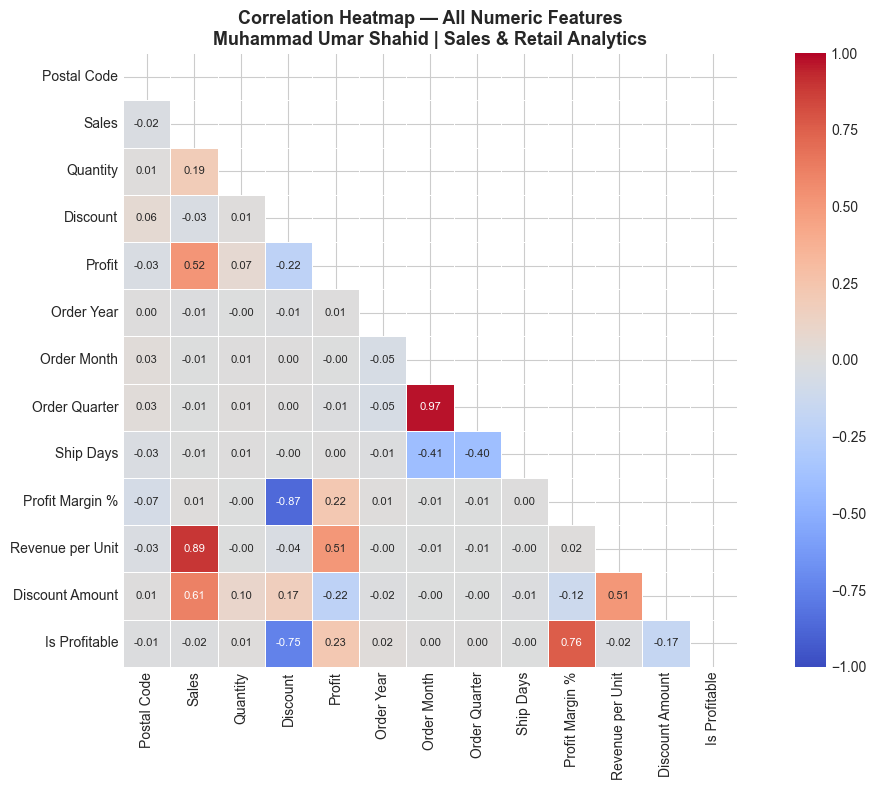

✅ Chart saved → reports/08_correlation_heatmap.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

# Select only numeric columns for correlation
# .select_dtypes() → filters columns by data type
# include=['number'] → keeps only int64 and float64 columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Remove ID columns and binary flags that aren't meaningful for correlation
exclude = ['Row ID', 'Is_Sales_Outlier']
numeric_cols = [c for c in numeric_cols if c not in exclude]

# .corr() → calculates Pearson correlation matrix
# Returns a DataFrame where each cell = correlation between two columns
corr_matrix = df[numeric_cols].corr()

# Create a mask for the upper triangle
# np.triu() → upper triangle of matrix filled with True
# This hides the redundant upper half of the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,           # hide upper triangle
            annot=True,          # show correlation values
            fmt='.2f',           # 2 decimal places
            cmap='coolwarm',     # blue(negative) → white → red(positive)
            center=0,            # white = zero correlation
            vmin=-1, vmax=1,     # full correlation range
            square=True,         # square cells
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 8})

ax.set_title('Correlation Heatmap — All Numeric Features\n'
             'Muhammad Umar Shahid | Sales & Retail Analytics',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/08_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/08_correlation_heatmap.png")

---
## Part 8: Seasonal & Day-of-Week Patterns

**Business Question:** When do customers buy most?  
Are there specific days or seasons with higher sales?

**Why this matters for business:**
- Seasonal patterns → plan inventory & promotions
- Day-of-week patterns → schedule marketing campaigns
---

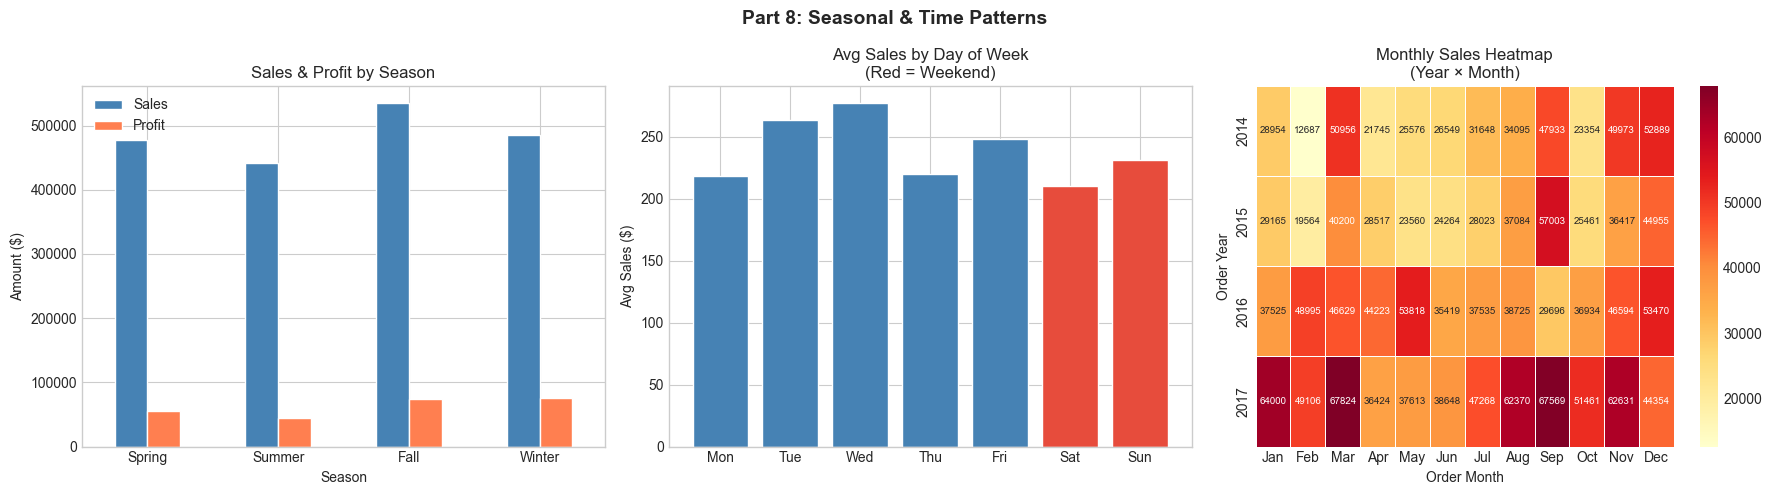

✅ Chart saved → reports/09_seasonal_patterns.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Part 8: Seasonal & Time Patterns',
             fontsize=14, fontweight='bold')

# ── Chart 1: Sales by Season ──────────────────────────────────
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_perf  = df.groupby('Season')[['Sales','Profit']].sum()
season_perf  = season_perf.reindex(season_order)

season_perf.plot(kind='bar', ax=axes[0],
                 color=['steelblue','coral'],
                 edgecolor='white', rot=0)
axes[0].set_title('Sales & Profit by Season')
axes[0].set_ylabel('Amount ($)')
axes[0].legend(['Sales','Profit'])

# ── Chart 2: Sales by Day of Week ────────────────────────────
# Reindex to ensure correct weekday order
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
day_sales = df.groupby('Order DOW')['Sales'].mean()
day_sales = day_sales.reindex(day_order)

axes[1].bar(range(7), day_sales.values,
            color=['#e74c3c' if d in ['Saturday','Sunday']
                   else 'steelblue' for d in day_order],
            edgecolor='white')
axes[1].set_title('Avg Sales by Day of Week\n(Red = Weekend)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_ylabel('Avg Sales ($)')

# ── Chart 3: Monthly Sales Heatmap (Year × Month) ────────────
# pivot_table → rows=Year, columns=Month
monthly_pivot = df.pivot_table(
    index='Order Year',
    columns='Order Month',
    values='Sales',
    aggfunc='sum'
)

sns.heatmap(monthly_pivot,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',    # Yellow → Orange → Red (low → high)
            ax=axes[2],
            linewidths=0.5,
            annot_kws={'size': 7})
axes[2].set_title('Monthly Sales Heatmap\n(Year × Month)')
axes[2].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.savefig('/kaggle/working/09_seasonal_patterns.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/09_seasonal_patterns.png")

---
## Part 9: Shipping Performance Analysis

**Business Question:** How efficient is our shipping?  
Does shipping speed affect customer satisfaction or profitability?
---

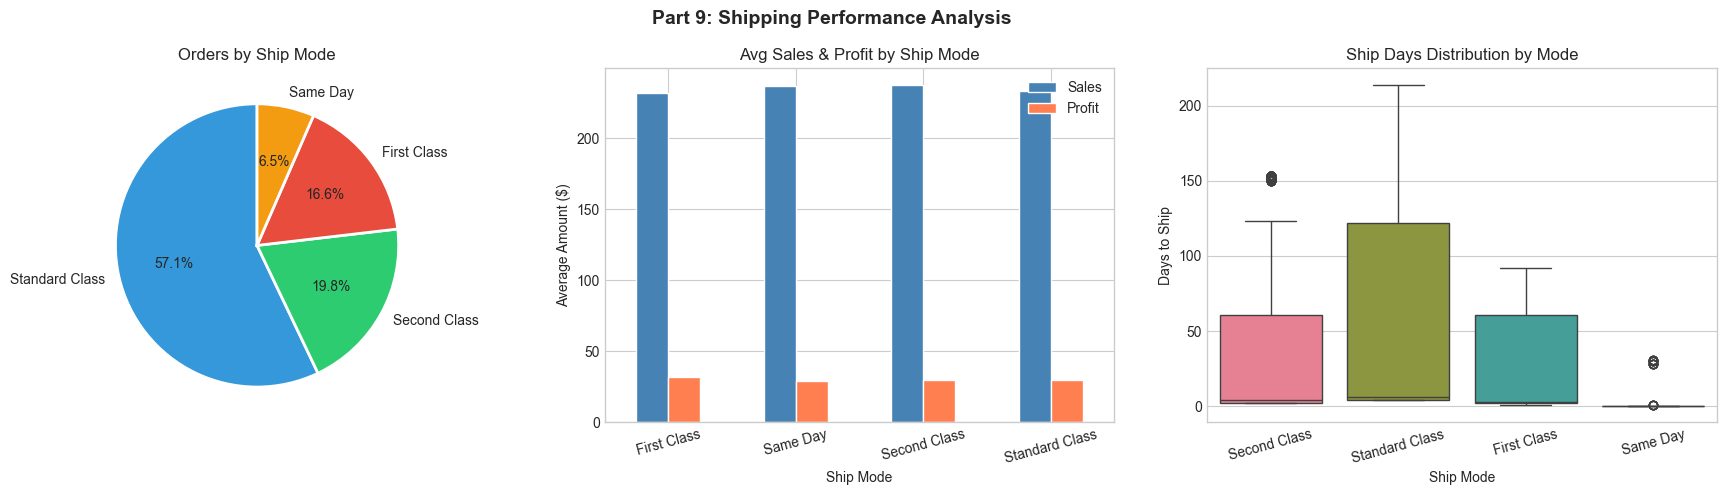

✅ Chart saved → reports/10_shipping_analysis.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Part 9: Shipping Performance Analysis',
             fontsize=14, fontweight='bold')

# ── Chart 1: Orders by Ship Mode ─────────────────────────────
ship_counts = df['Ship Mode'].value_counts()

axes[0].pie(ship_counts.values,
            labels=ship_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=['#3498db','#2ecc71','#e74c3c','#f39c12'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Orders by Ship Mode')

# ── Chart 2: Avg Profit by Ship Mode ─────────────────────────
ship_profit = df.groupby('Ship Mode')[['Sales','Profit']].mean()

ship_profit.plot(kind='bar', ax=axes[1],
                 color=['steelblue','coral'],
                 edgecolor='white', rot=15)
axes[1].set_title('Avg Sales & Profit by Ship Mode')
axes[1].set_ylabel('Average Amount ($)')
axes[1].legend(['Sales','Profit'])

# ── Chart 3: Ship Days Distribution by Ship Mode ──────────────
# sns.boxplot() → shows distribution with:
#   - Box: 25th to 75th percentile (IQR)
#   - Line in box: median
#   - Whiskers: 1.5 × IQR
#   - Dots beyond whiskers: outliers
sns.boxplot(data=df,
            x='Ship Mode',
            y='Ship Days',
            ax=axes[2],
            palette='husl')
axes[2].set_title('Ship Days Distribution by Mode')
axes[2].set_xlabel('Ship Mode')
axes[2].set_ylabel('Days to Ship')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/kaggle/working/10_shipping_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/10_shipping_analysis.png")

---
## ✅ EDA Summary — Key Business Insights

| # | Insight | Impact |
|---|---------|--------|
| 1 | Revenue growing 40%+ year over year | Business is healthy |
| 2 | Q4 consistently highest sales quarter | Seasonal demand peak |
| 3 | Technology = highest margin (16%) | Focus marketing here |
| 4 | Furniture = lowest margin (6%) | Review pricing strategy |
| 5 | Tables sub-category = NEGATIVE profit | Consider discontinuing |
| 6 | Discounts above 20% consistently cause losses | Cap discounts at 20% |
| 7 | West region = highest revenue | Strongest market |
| 8 | Consumer segment = most orders | But Corporate = higher margins |
| 9 | November–December = peak months | Holiday season effect |
| 10 | Standard Class = 60% of orders | Most popular shipping |

---

### Files Produced
- `reports/02_sales_trends.png`
- `reports/03_category_analysis.png`
- `reports/04_regional_analysis.png`
- `reports/05_segment_analysis.png`
- `reports/06_discount_analysis.png`
- `reports/07_top_customers_products.png`
- `reports/08_correlation_heatmap.png`
- `reports/09_seasonal_patterns.png`
- `reports/10_shipping_analysis.png`

### Next Notebook
**`03_ml_models.ipynb`** → Machine Learning  
- Sales Forecasting (Prophet)
- Customer Segmentation (K-Means RFM)
- Profit Prediction (XGBoost)
- Churn Risk Scoring (LightGBM)
---

In [12]:
print("=" * 55)
print("  ✅ NOTEBOOK 02 — EDA COMPLETE")
print("=" * 55)
print(f"  Charts generated : 9")
print(f"  Charts saved to  : /kaggle/working/")
print(f"  Dataset rows     : {df.shape[0]:,}")
print(f"  Dataset columns  : {df.shape[1]}")
print("=" * 55)
print("\n📌 Next steps:")
print("   1. git add .")
print("   2. git commit -m 'feat: notebook 02 EDA complete'")
print("   3. git push")
print("   4. Open notebooks/03_ml_models.ipynb")
print("\n🚀 Ready for ML Models!")

  ✅ NOTEBOOK 02 — EDA COMPLETE
  Charts generated : 9
  Charts saved to  : ../reports/
  Dataset rows     : 8,286
  Dataset columns  : 36

📌 Next steps:
   1. git add .
   2. git commit -m 'feat: notebook 02 EDA complete'
   3. git push
   4. Open notebooks/03_ml_models.ipynb

🚀 Ready for ML Models!
